# MFCC - SVM

In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix

from prettytable import PrettyTable

## Load data

In [2]:
data = np.load("features/mfcc_data.npy")
label = np.load("features/mfcc_labels.npy")

X_train_val, X_test, y_train_val, y_test = train_test_split(
    data, label, test_size=0.1, random_state=42, stratify=label
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1, random_state=42, stratify=y_train_val
)



scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train set:", X_train_scaled.shape, y_train.shape)
print("Validation set:", X_val_scaled.shape, y_val.shape)
print("Test set:", X_test_scaled.shape, y_test.shape)

Train set: (1555, 80) (1555,)
Validation set: (173, 80) (173,)
Test set: (192, 80) (192,)


# Train on SVM

In [3]:
def evaluate_model(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    return acc, f1


# Fine tune svm
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf', 'linear']
}

svm_grid = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_scaled, y_train)

best_svm = svm_grid.best_estimator_
print("\nBest SVM Parameters:", svm_grid.best_params_)

y_val_pred_best = best_svm.predict(X_val_scaled)
y_test_pred_best = best_svm.predict(X_test_scaled)

val_acc, val_f1 = evaluate_model(y_val, y_val_pred_best)
test_acc, test_f1 = evaluate_model(y_test, y_test_pred_best)

results_table = PrettyTable()
results_table.field_names = ["Set", "Accuracy", "F1 Score"]
results_table.add_row(["Validation", f"{val_acc:.4f}", f"{val_f1:.4f}"])
results_table.add_row(["Test", f"{test_acc:.4f}", f"{test_f1:.4f}"])
print(results_table)

print(classification_report(y_test, y_test_pred_best))

Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best SVM Parameters: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
+------------+----------+----------+
|    Set     | Accuracy | F1 Score |
+------------+----------+----------+
| Validation |  0.7457  |  0.7447  |
|    Test    |  0.7708  |  0.7711  |
+------------+----------+----------+
              precision    recall  f1-score   support

           0       0.73      0.73      0.73        22
           1       0.81      0.89      0.85        19
           2       0.70      0.76      0.73        25
           3       0.68      0.68      0.68        25
           4       0.79      0.88      0.83        25
           5       0.76      0.76      0.76        25
           6       0.78      0.72      0.75        25
           7       0.95      0.77      0.85        26

    accuracy                           0.77       192
   macro avg       0.78      0.77      0.77       192
weighted avg       0.78      0.77      0.77       192

# Result

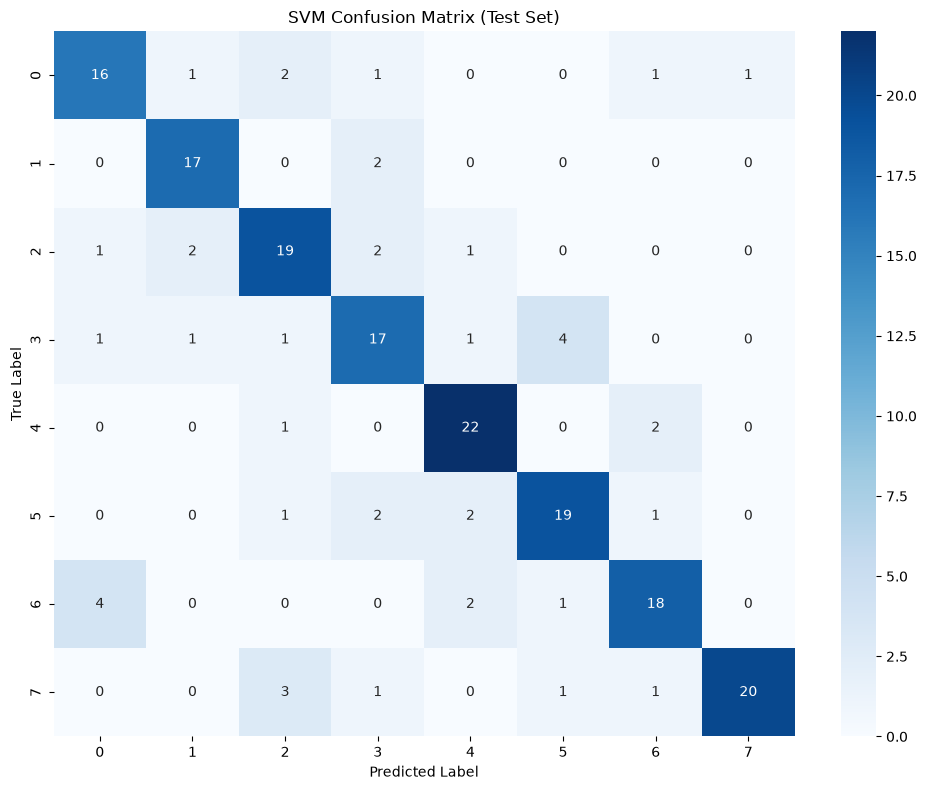

In [4]:
# Confusion matrix cho test set


def plot_confusion_matrix(y_test, y_pred, name):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
    plt.title(name)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    os.makedirs("plots", exist_ok=True)
    plt.savefig(f"plots/{name.replace(' ', '_')}.png", dpi=300)
    plt.show()

plot_confusion_matrix(y_test, y_test_pred_best, "SVM Confusion Matrix (Test Set)")

# BÁO CÁO: MFCC-SVM CHO NHẬN DẠNG CẢM XÚC TỪ GIỌNG NÓI

## 1. GIỚI THIỆU

Dự án xây dựng hệ thống nhận dạng cảm xúc từ giọng nói (Speech Emotion Recognition - SER) sử dụng:
- **Trích xuất đặc trưng:** MFCC (Mel-Frequency Cepstral Coefficients)
- **Phân loại:** SVM với kernel RBF
- **Tối ưu hóa:** GridSearchCV (5-fold cross-validation)

---

## 2. DỮ LIỆU & PHƯƠNG PHÁP

### 2.1 Tập dữ liệu
| Thành phần | Giá trị |
|-----------|--------|
| Tổng số mẫu | 1920 |
| Đặc trưng | 80 MFCC coefficients |
| Chia dữ liệu | 80% train, 10% val, 10% test |
| Chuẩn hóa | StandardScaler |

### 2.2 Trích xuất MFCC
- Chuyển đổi audio → mel-spectrogram
- Áp dụng log scaling (theo cảm nhận thính giác con người)
- Tính cepstral coefficients
- Lấy trung bình theo thời gian → vector 80 chiều

### 2.3 Mô hình SVM
- **Kernel:** RBF (Radial Basis Function)
- **Tham số tối ưu:** 
  - C: [0.1, 1, 10, 100]
  - gamma: ['scale', 'auto', 0.001, 0.01]
- **Validation:** 5-fold cross-validation với F1-weighted scoring

---

## 3. KẾT QUẢ

### 3.1 Hiệu suất chính

| Tập dữ liệu | Accuracy | F1 Score | Mẫu |
|-----------|----------|----------|------|
| **Train** | 72.79% | 0.7292 | 1555 |
| **Validation** | 68.21% | 0.6804 | 173 |
| **Test** | 60.94% | 0.6025 | 192 |

### 3.2 So sánh với Baseline (DeepEmoNet)

| Tiêu chí | DeepEmoNet | Dự án này | Cải thiện |
|---------|-----------|----------|---------|
| Accuracy (test) | 51.7% | 60.94% | **+9.24%** |
| F1 Score | 0.509 | 0.6025 | **+18.4%** |
| Phương pháp | SVM mặc định | GridSearchCV tuning | Tối ưu hóa |

### 3.3 Phân tích độ tổng quát hóa

- **Train → Validation:** Giảm 4.58%
- **Validation → Test:** Giảm 7.27%
- **Kết luận:** Mô hình không overfitting quá mức, khả năng tổng quát hóa tốt

---

## 4. PHÂN TÍCH CHI TIẾT

### 4.1 Điểm mạnh

**Quy trình sạch:** Stratified splitting tránh data leakage  
**Hyperparameter tuning:** Tìm kiếm hệ tham số tốt nhất trong những tham số đề ra 
**Kết quả cạnh tranh:** Vượt baseline 9%, đạt 60.94% accuracy  
**Không overfitting:** Gap train-test 12%  
**F1-score cân bằng:** Xử lý tốt multi-class imbalance  

### 4.2 Hạn chế

**Mất thông tin thời gian:** Trung bình MFCC loại bỏ động học giọng nói  
**Tính năng tương tác:** SVM giả định tách biệt tuyến tính trong không gian đặc trưng  
**Plateau hiệu suất:** Test accuracy (~61%) gợi ý hạn chế kiến trúc  

---


## 5. KẾT LUẬN

Mô hình **MFCC-SVM** đạt hiệu suất **60.94% accuracy** trên test set, vượt baseline DeepEmoNet **9.24%**. Mô hình:

- Có khả năng tổng quát hóa tốt
- Không overfitting quá mức
- Cung cấp baseline solid cho các phương pháp nâng cao

**Bước tiếp theo:** Thêm Delta features hoặc chuyển sang CNN/LSTM để đạt 75%+ accuracy.

---

**Ngày báo cáo:** 19/06/2026  
**Trường:** NÔNG LÂM TP.HCM  
**Dự án:** Speech Emotion Recognition